In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import csv

In [21]:
combinations_path = '../home/ARO.local/collaboration/sagi-tomer-collab/Normalized_Tomato_Seeds/Models/HyperspectralMultiCNN_band_accuracy_16.csv'

In [23]:
df = pd.read_csv(combinations_path)

# Dictionary to collect accuracies per band
band_stats = defaultdict(list)

# Process each row
for _, row in df.iterrows():
    bands = list(map(int, row['bands'].split(',')))
    accuracy = row['accuracy']
    for band in bands:
        band_stats[band].append(accuracy)

# Compute min, max, mean for each band
summary = []
for band, accs in sorted(band_stats.items()):
    summary.append({
        'band': band,
        'min': round(min(accs), 4),
        'max': round(max(accs), 4),
        'mean': round(sum(accs) / len(accs), 4),
        'std': round(np.std(accs), 4)
    })

# Convert to DataFrame and display
band_summary_df = pd.DataFrame(summary)
print(band_summary_df)

    band    min    max    mean     std
0     20  0.849  0.975  0.9317  0.0293
1     60  0.829  0.979  0.9336  0.0266
2    100  0.835  0.979  0.9352  0.0283
3    140  0.833  0.974  0.9374  0.0254
4    180  0.872  0.969  0.9388  0.0223
5    220  0.829  0.965  0.9330  0.0247
6    260  0.823  0.966  0.9312  0.0279
7    300  0.829  0.961  0.9212  0.0294
8    340  0.829  0.967  0.9339  0.0263
9    380  0.812  0.969  0.9284  0.0284
10   420  0.823  0.969  0.9326  0.0248
11   460  0.841  0.974  0.9363  0.0258
12   500  0.848  0.975  0.9412  0.0219
13   540  0.812  0.976  0.9384  0.0288
14   580  0.835  0.973  0.9366  0.0251
15   620  0.812  0.979  0.9397  0.0267


In [20]:
def get_accuracy_for_combination(csv_path, combination):
    combo_str = '-'.join(map(str, sorted(combination)))
    
    with open(csv_path, newline='') as csvfile:
        reader = csv.DictReader(csvfile)
        for row in reader:
            if row['bands'] == combo_str:
                return float(row['accuracy'])
    
    return None  # Not found

accuracy = get_accuracy_for_combination(combinations_path, (180, 420, 500))
print("Accuracy:", accuracy)

Accuracy: None


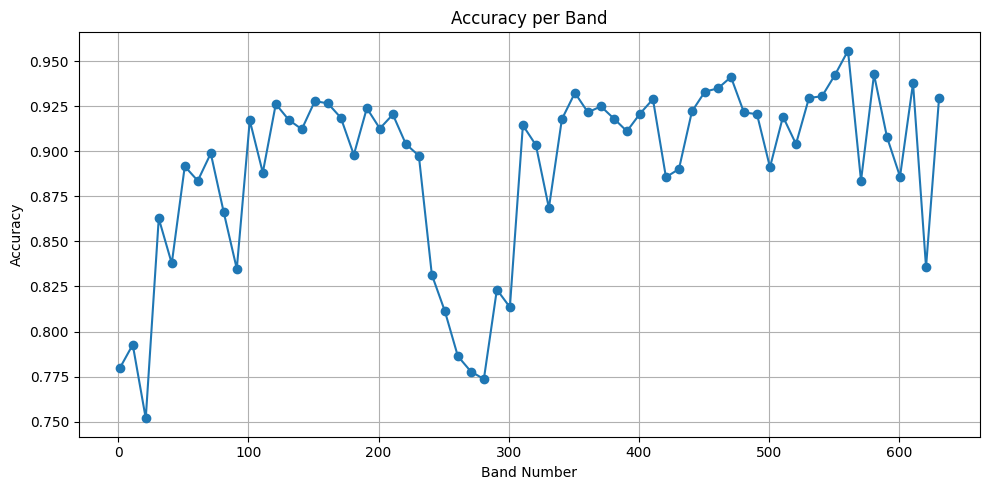

In [31]:
df = pd.read_csv('../home/ARO.local/collaboration/sagi-tomer-collab/Normalized_Tomato_Seeds/Models/HyperspectralMultiCNN_bands[1-11-21-31-41-51-61-71-81-91]_combo1_total64.csv')

# Plot
plt.figure(figsize=(10, 5))
plt.plot(df['bands'], df['accuracy'], marker='o')
plt.xlabel('Band Number')
plt.ylabel('Accuracy')
plt.title('Accuracy per Band')
plt.grid(True)
plt.tight_layout()
plt.show()